# Convolutional Neural Network (CNN)

Implementar un modelo de clasificación de imágenes usando CNN.

### Objetivo:
- Entrenar una red pequeña usando el dataset CIFAR-10.

### Puntos Clave:
- Verificar si hubo overfitting usando gráficas de Loss y Accuracy de train vs val.
- Genearar la matriz de confusión detallada y un reporte de clasificación por cada clase.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.3887 - loss: 1.6774 - val_accuracy: 0.5117 - val_loss: 1.3776
Epoch 2/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5109 - loss: 1.3624 - val_accuracy: 0.5712 - val_loss: 1.2088
Epoch 3/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.5574 - loss: 1.2345 - val_accuracy: 0.6044 - val_loss: 1.1363
Epoch 4/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.5902 - loss: 1.1568 - val_accuracy: 0.6414 - val_loss: 1.0416
Epoch 5/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6142 - loss: 1.0876 - val_accuracy: 0.6561 - val_loss: 0.9947
Epoch 6/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.6333 - loss: 1.0401 - val_accuracy: 0.6553 - val_loss: 0.9979
Epoch 7/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6483 - loss: 0.9935 - val_accuracy: 0.6765 - val_loss: 0.9377
Epoch 8/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6578 - loss: 0.9649 - 

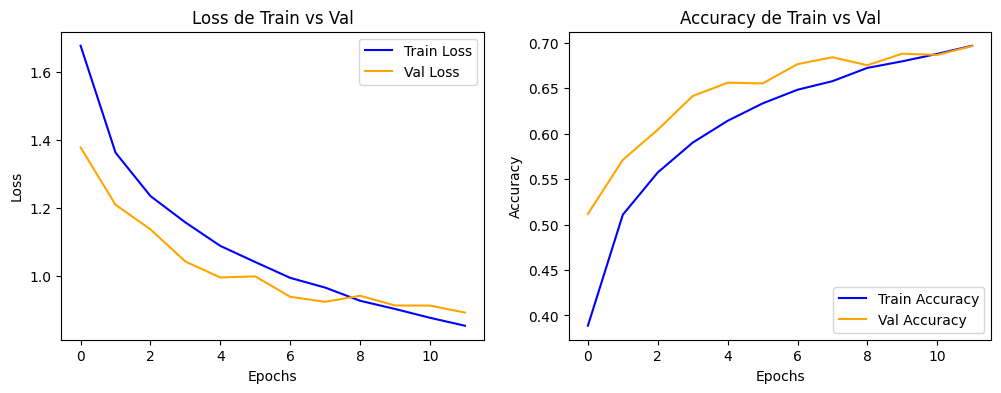

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


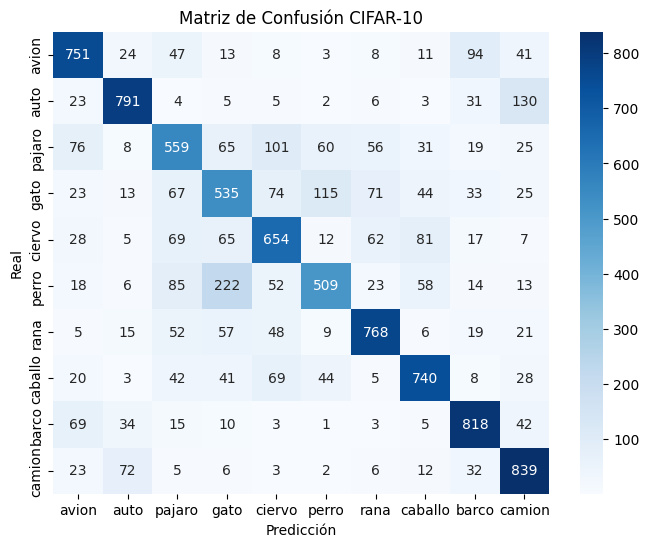


REPORTE DE CLASIFICACION POR CLASE:
------------------------------------------------------------
              precision    recall  f1-score   support

       avion       0.72      0.75      0.74      1000
        auto       0.81      0.79      0.80      1000
      pajaro       0.59      0.56      0.57      1000
        gato       0.53      0.54      0.53      1000
      ciervo       0.64      0.65      0.65      1000
       perro       0.67      0.51      0.58      1000
        rana       0.76      0.77      0.76      1000
     caballo       0.75      0.74      0.74      1000
       barco       0.75      0.82      0.78      1000
      camion       0.72      0.84      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.69     10000
weighted avg       0.70      0.70      0.69     10000



In [1]:
# CLASIFICACION DE IMAGENES CON CNN (CIFAR-10)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

# CARGAR Y NORMALIZAR DATASET
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

class_names = ['avion', 'auto', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion']

# CONSTRUCCION DE LA RED CONVOLUCIONAL PEQUEÑA
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3), # CONTROL DE OVERFITTING
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train, epochs=12, batch_size=64, validation_data=(X_test, Y_test))

# GRAFICAS DE METRICAS (DETECCION DE OVERFITTING)
plt.figure(figsize=(12, 4))

# Grafica de Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss de Train vs Val')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Grafica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Accuracy de Train vs Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# EVALUACION Y PREDICCIONES
Y_pred_probs = model.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)

# MATRIZ DE CONFUSION DETALLADA
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión CIFAR-10')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# REPORTE DE CLASIFICACION POR CLASE
print("\nREPORTE DE CLASIFICACION POR CLASE:")
print("-"*60)
print(classification_report(Y_test, Y_pred, target_names=class_names))

## Conclusiones

El modelo no presenta overfitting. Las curvas muestran una evolución equilibrada.

El modelo está generalizando bien porque el rendimiento en datos no vistos (validación) es equivalente al de los datos de entrenamiento al finalizar las 12 épocas.

El comportamiento de las curvas sugiere que el entrenamiento terminó en un buen momento, o incluso se prodria intentar entrenarlo por unas cuantas épocas más de forma controlada, para ver si logran romper la barrera del 70% y seguir subiendo antes de que la curva de validación empiece a degradarse.

Por motivos de capacidad dejamos el cuaderno en este punto.